
### Import libraries

In [26]:
import sys
from pathlib import Path
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

#### import functions

In [4]:
project_root = Path().resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [27]:
from helper_functions.simulation import generate_toy_logistic_data

### Code

In [37]:
data = generate_toy_logistic_data(n=1000,p=2,noise_level=0.2)
X = data["X"]
y_true = data["y_true"]
y_noisy = data["y_noisy"]
p_true = data["p_true"]
beta_true = data["beta_true"]
flip_mask = data["flip_mask"]


Lets take a look at our data

In [38]:
print(X.shape)

(1000, 2)


Lets fit our data

In [39]:
clf = LogisticRegression(
    solver="lbfgs",
    max_iter = 2000,
)

clf.fit(X,y_noisy)

intercept_hat = clf.intercept_[0]
beta_hat = clf.coef_.ravel()

print("Intercept hat", intercept_hat)
print("Beta hat", beta_hat)


Intercept hat 0.013228213871360781
Beta hat [ 0.43893088 -0.21027458]


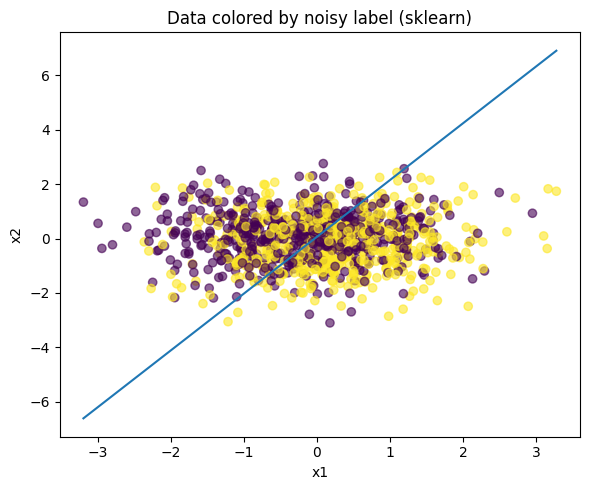

In [40]:
if X.shape[1] == 2:
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y_noisy, alpha=0.6)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Data colored by noisy label (sklearn)")

    # boundary: intercept + b1*x1 + b2*x2 = 0
    x1_grid = np.linspace(X[:, 0].min(), X[:, 0].max(), 200)
    b0 = intercept_hat
    b1, b2 = beta_hat[0], beta_hat[1]
    x2_grid = -(b0 + b1 * x1_grid) / b2

    plt.plot(x1_grid, x2_grid)
    plt.tight_layout()
    plt.show()
